# pinball — DQN vs. Random on Pinball `easy`

Overlays the two components (`random_easy`, `dqn_easy`) as episodic-return
curves with a mean ± 95% bootstrap-CI band over 30 seeds. Each component is
loaded from its own table in `results/pinball.db`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

_HERE = Path.cwd()
_EXP_DIR = _HERE if (_HERE / "config.py").exists() else Path("experiments/pinball")
sys.path.insert(0, str(_EXP_DIR))
sys.path.insert(0, str(_EXP_DIR.resolve().parents[1]))

from experiment import load_result, load_runs
from analysis.plotting import seed_grids_for, plot_mean_ci, style

from config import EXPERIMENT


def grid_for(component, n=500):
    """A shared [0, total_steps] timestep grid from any run's length."""
    df = load_runs(EXPERIMENT, component)
    total_steps = len(load_result(EXPERIMENT, component, df["run_id"][0])["reward"])
    return np.linspace(0, total_steps, n)


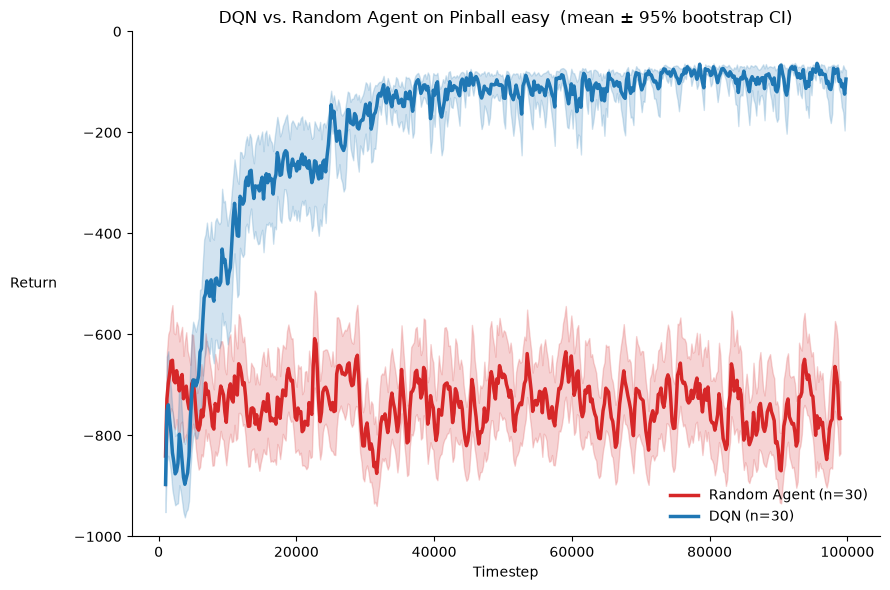

In [ ]:
HERE = Path.cwd()
RESULTS = HERE / "results" if (HERE / "results").exists() else Path("experiments/pinball/results")

# Both components run 100k steps, so they share one grid.
GRID = grid_for("dqn_easy")

series = [
    ("Random Agent", "tab:red", "random_easy"),
    ("DQN", "tab:blue", "dqn_easy"),
    ("DDQN", "tab:green", "ddqn_easy"),
]

fig, ax = plt.subplots(figsize=(9, 6))   # 2:3 height:width
for label, color, component in series:
    stack = seed_grids_for(EXPERIMENT, component, GRID)
    n = stack.shape[0]
    plot_mean_ci(ax, GRID, stack, f"{label} (n={n})", color)

ax.set_title("DQN vs. Random Agent on Pinball easy  (mean ± 95% bootstrap CI)")
ax.legend(loc="lower right", frameon=False)
style(ax, ylim=(-1000, 0))
fig.tight_layout()
plt.show()


In [ ]:
PLOTS_DIR = RESULTS.parent / "plots"
PLOTS_DIR.mkdir(exist_ok=True)
fig.savefig(PLOTS_DIR / "pinball_random_vs_dqn.pdf", bbox_inches="tight")
print(f"saved plot to {PLOTS_DIR / 'pinball_random_vs_dqn.pdf'}")
